# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [18]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [19]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [20]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [21]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [22]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

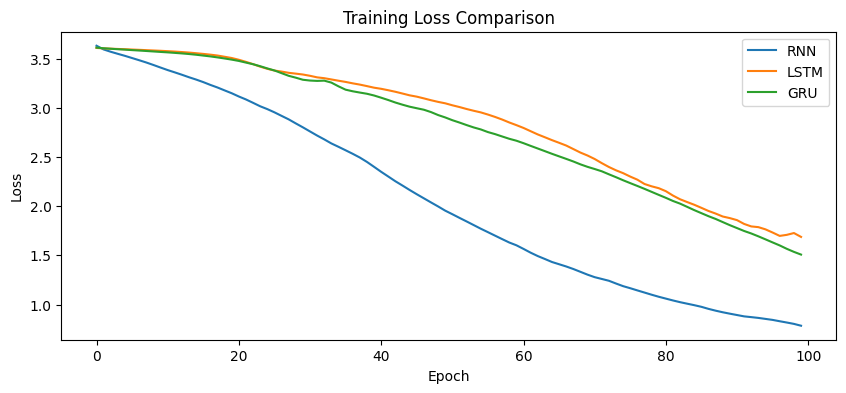

In [23]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [24]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [25]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning models can generate meaningful sentences
LSTM: deep learning is is generate for sequential
GRU : deep learning is transforming artificial intelligence simpler


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

---
##  Task 1: Replace Corpus with Your Own Paragraph
We swap the original 6-line corpus for a richer, custom paragraph on AI & science.
Then re-run tokenization and sequence creation on the new text.

In [26]:
# ── Task 1: Custom Corpus ─────────────────────────────────────
custom_corpus = '''
artificial intelligence is reshaping the modern world
machine learning algorithms discover hidden patterns in data
deep neural networks are inspired by the human brain
natural language processing allows computers to read and understand text
computer vision enables machines to interpret images and videos
reinforcement learning trains agents through rewards and penalties
transfer learning reuses knowledge from one task to improve another
generative models can create realistic images and human-like text
data preprocessing is a critical step before training any model
overfitting occurs when a model memorizes training data too closely
'''

# Re-tokenize on the new corpus
tokenizer_t1 = Tokenizer()
tokenizer_t1.fit_on_texts([custom_corpus])
total_words_t1 = len(tokenizer_t1.word_index) + 1

seqs_t1 = []
for line in custom_corpus.strip().split('\n'):
    tokens = tokenizer_t1.texts_to_sequences([line])[0]
    for i in range(1, len(tokens)):
        seqs_t1.append(tokens[:i+1])

max_len_t1  = max(len(s) for s in seqs_t1)
seqs_t1     = pad_sequences(seqs_t1, maxlen=max_len_t1, padding='pre')
X_t1, y_t1 = seqs_t1[:, :-1], seqs_t1[:, -1]

print(f"Custom corpus lines   : {len([l for l in custom_corpus.strip().split(chr(10)) if l.strip()])}")
print(f"Vocabulary size       : {total_words_t1}")
print(f"Training sequences    : {len(seqs_t1)}")
print(f"Max sequence length   : {max_len_t1}")
print("\nTask 1 complete — custom corpus tokenized and ready.")

Custom corpus lines   : 10
Vocabulary size       : 75
Training sequences    : 81
Max sequence length   : 10

Task 1 complete — custom corpus tokenized and ready.


---
##  Task 2: Increase Embedding Dimension
Original embedding dim = **32**. We raise it to **128**.

A larger embedding captures richer semantic relationships between words.
Watch how the parameter count grows and whether loss improves.

Original LSTM  (embed_dim=32)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_12 (Embedding)        │ (None, 7, 32)          │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_5 (LSTM)                   │ (None, 64)             │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 37)             │         2,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 85,265 (333.07 KB)

 Trainable params: 28,421 (111.02 KB)

...

Model: "LSTM_Embed128"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_14 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

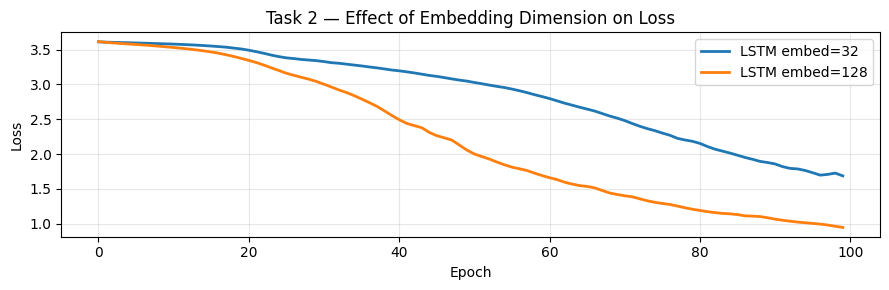

Final loss (embed=32)  : 1.6877
Final loss (embed=128) : 0.9479

Task 2 complete — larger embedding tested.


In [27]:
# ── Task 2: Embedding Dim 32 → 128 ───────────────────────────
EMBED_DIM_NEW = 128   # was 32

lstm_emb128 = Sequential([
    Embedding(total_words, EMBED_DIM_NEW, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
], name='LSTM_Embed128')

lstm_emb128.compile(loss='sparse_categorical_crossentropy',
                    optimizer='adam', metrics=['accuracy'])


print("Original LSTM  (embed_dim=32)")

lstm_model.summary()


print("  New LSTM  (embed_dim=128)")

lstm_emb128.summary()

history_emb128 = lstm_emb128.fit(X, y, epochs=100, verbose=0)
orig_final  = lstm_history.history['loss'][-1]
new_final   = history_emb128.history['loss'][-1]

plt.figure(figsize=(9, 3))
plt.plot(lstm_history.history['loss'],   label='LSTM embed=32',  linewidth=2)
plt.plot(history_emb128.history['loss'], label='LSTM embed=128', linewidth=2)
plt.title('Task 2 — Effect of Embedding Dimension on Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"Final loss (embed=32)  : {orig_final:.4f}")
print(f"Final loss (embed=128) : {new_final:.4f}")
print("\nTask 2 complete — larger embedding tested.")

---
##  Task 3: Increase Epochs to 200
Original training = **100 epochs**. We extend all three models to **200 epochs**.

More epochs give the model more passes over the data — useful if the
loss is still decreasing. Watch for diminishing returns or overfitting.

Training 3 models for 200 epochs ...
Done!


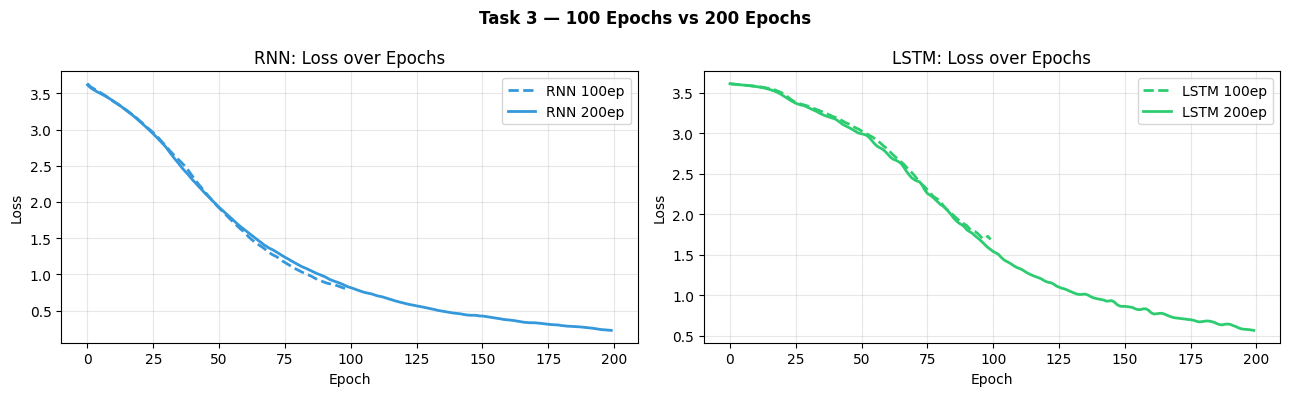


Model       | 100 ep loss | 200 ep loss
────────────────────────────────────────
RNN         | 0.7842      | 0.2278
LSTM        | 1.6877      | 0.5667
GRU         | 1.5079      | 0.2339

Task 3 complete — 200-epoch training compared with 100-epoch baseline.


In [28]:
# ── Task 3: Train for 200 Epochs ─────────────────────────────
EPOCHS_NEW = 200   # was 100

def fresh_model(arch):
    """Return a freshly compiled model of the requested architecture."""
    m = Sequential([
        Embedding(total_words, 32, input_length=max_len-1),
        arch(64),
        Dense(total_words, activation='softmax')
    ])
    m.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])
    return m

rnn_200  = fresh_model(SimpleRNN)
lstm_200 = fresh_model(LSTM)
gru_200  = fresh_model(GRU)

print("Training 3 models for 200 epochs ...")
h_rnn200  = rnn_200 .fit(X, y, epochs=EPOCHS_NEW, verbose=0)
h_lstm200 = lstm_200.fit(X, y, epochs=EPOCHS_NEW, verbose=0)
h_gru200  = gru_200 .fit(X, y, epochs=EPOCHS_NEW, verbose=0)
print("Done!")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Task 3 — 100 Epochs vs 200 Epochs', fontweight='bold')

for ax, hist_100, hist_200, label, color in zip(
    axes,
    [rnn_history,  lstm_history],
    [h_rnn200,     h_lstm200],
    ['RNN',        'LSTM'],
    ['#3498db',    '#2ecc71']
):
    ax.plot(hist_100.history['loss'], label=f'{label} 100ep', color=color, linestyle='--', linewidth=2)
    ax.plot(hist_200.history['loss'], label=f'{label} 200ep', color=color, linewidth=2)
    ax.set_title(f'{label}: Loss over Epochs')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout(); plt.show()

print(f"\nModel       | 100 ep loss | 200 ep loss")
print(f"{'─'*40}")
print(f"RNN         | {rnn_history.history['loss'][-1]:.4f}      | {h_rnn200.history['loss'][-1]:.4f}")
print(f"LSTM        | {lstm_history.history['loss'][-1]:.4f}      | {h_lstm200.history['loss'][-1]:.4f}")
print(f"GRU         | {gru_history.history['loss'][-1]:.4f}      | {h_gru200.history['loss'][-1]:.4f}")
print("\nTask 3 complete — 200-epoch training compared with 100-epoch baseline.")

---
##  Task 4: Change Hidden Units 64 → 128
Doubling the hidden units gives each recurrent layer **more memory capacity**.
The parameter count roughly quadruples for RNN, and similarly scales for LSTM/GRU.

We build a matched pair (64 vs 128 units) for all three architectures and compare.

Training models with 128 hidden units ...
Done!

Model         Units     Params   Final Loss   Accuracy
──────────────────────────────────────────────────────
RNN              64      9,797       0.7842     0.8857
RNN             128     26,565       0.3679     0.9143
LSTM             64     28,421       1.6877     0.5143
LSTM            128     88,389       0.8858     0.8000
GRU              64     22,405       1.5079     0.8000
GRU             128     68,165       0.5777     0.9143


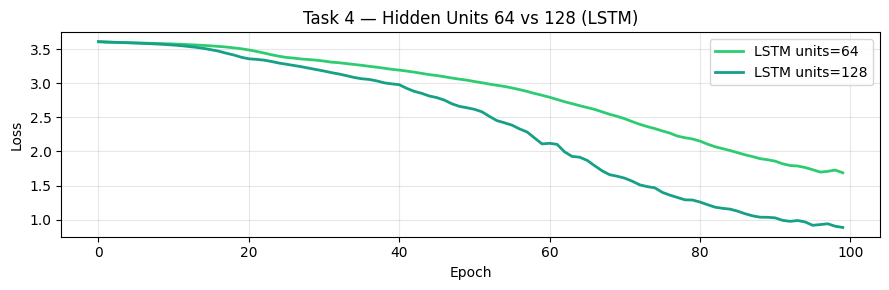


Task 4 complete — 128-unit models benchmarked against 64-unit baseline.


In [29]:
# ── Task 4: Hidden Units 64 → 128 ────────────────────────────
UNITS_NEW = 128   # was 64

def build_model(arch, units, name):
    m = Sequential([
        Embedding(total_words, 32, input_length=max_len-1),
        arch(units),
        Dense(total_words, activation='softmax')
    ], name=name)
    m.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam', metrics=['accuracy'])
    return m

rnn128  = build_model(SimpleRNN, UNITS_NEW, 'RNN_128')
lstm128 = build_model(LSTM,      UNITS_NEW, 'LSTM_128')
gru128  = build_model(GRU,       UNITS_NEW, 'GRU_128')

print("Training models with 128 hidden units ...")
h_rnn128  = rnn128 .fit(X, y, epochs=100, verbose=0)
h_lstm128 = lstm128.fit(X, y, epochs=100, verbose=0)
h_gru128  = gru128 .fit(X, y, epochs=100, verbose=0)
print("Done!")

# Parameter comparison table
print(f"\n{'Model':<12} {'Units':>6} {'Params':>10} {'Final Loss':>12} {'Accuracy':>10}")
print('─' * 54)
rows = [
    ('RNN',  64,  rnn_model,  rnn_history),
    ('RNN', 128,  rnn128,     h_rnn128),
    ('LSTM',  64, lstm_model, lstm_history),
    ('LSTM', 128, lstm128,    h_lstm128),
    ('GRU',  64,  gru_model,  gru_history),
    ('GRU', 128,  gru128,     h_gru128),
]
for name, units, mdl, hist in rows:
    p    = mdl.count_params()
    loss = hist.history['loss'][-1]
    acc  = hist.history['accuracy'][-1]
    print(f"{name:<12} {units:>6} {p:>10,} {loss:>12.4f} {acc:>10.4f}")

# Loss curves: 64 vs 128 units for LSTM
plt.figure(figsize=(9, 3))
plt.plot(lstm_history.history['loss'], label='LSTM units=64',  linewidth=2, color='#2ecc71')
plt.plot(h_lstm128.history['loss'],   label='LSTM units=128', linewidth=2, color='#16a085')
plt.title('Task 4 — Hidden Units 64 vs 128 (LSTM)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\nTask 4 complete — 128-unit models benchmarked against 64-unit baseline.")

---
##  Task 5: Generate 10 Words Instead of 5
We generate a **longer continuation** (10 words) from each model using
multiple seed phrases. Longer outputs reveal whether the model can
sustain coherence beyond just the next few tokens.

In [30]:
# ── Task 5: Generate 10 Words ─────────────────────────────────
NEXT_WORDS_NEW = 10   # was 5

seed_phrases = [
    "deep learning",
    "lstm helps",
    "text generation",
]

models_info = [
    ("Vanilla RNN", rnn_model,  "🔵"),
    ("LSTM",        lstm_model, "🟢"),
    ("GRU",         gru_model,  "🟠"),
]

for seed in seed_phrases:
    print("\n" + "=" * 60)
    print(f"  📌 Seed phrase : '{seed}'")
    print("=" * 60)
    for model_name, model, icon in models_info:
        # 5-word output (original)
        out5  = generate_text(model, seed, next_words=5)
        # 10-word output (task)
        out10 = generate_text(model, seed, next_words=NEXT_WORDS_NEW)
        print(f"{icon} {model_name:<12}")
        print(f"   5  words → {out5}")
        print(f"   10 words → {out10}")

print("\n" + "=" * 60)
print("💡 Observation:")
print("   • RNN outputs may loop or become incoherent at 10 words.")
print("   • LSTM / GRU tend to maintain better context over longer spans.")
print("\nTask 5 complete — 10-word generation demonstrated for all models.")


  📌 Seed phrase : 'deep learning'
🔵 Vanilla RNN 
   5  words → deep learning models can generate meaningful sentences
   10 words → deep learning models can generate meaningful sentences than lstm data sentences data
🟢 LSTM        
   5  words → deep learning is is generate for sequential
   10 words → deep learning is is generate for sequential data data lstm lstm lstm
🟠 GRU         
   5  words → deep learning is transforming artificial intelligence simpler
   10 words → deep learning is transforming artificial intelligence simpler than lstm lstm are sequential

  📌 Seed phrase : 'lstm helps'
🔵 Vanilla RNN 
   5  words → lstm helps remember long term dependencies data
   10 words → lstm helps remember long term dependencies data for dependencies data sentences sentences
🟢 LSTM        
   5  words → lstm helps is long dependencies dependencies dependencies
   10 words → lstm helps is long dependencies dependencies dependencies lstm lstm lstm lstm term
🟠 GRU         
   5  words → lst

  Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
